<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/03MIAR_MCarmenCopeSoler_AG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03MIAR - Algoritmos de optimización
## Actividad guiada 2

*Mª Carmen Copé Soler*

## Presentación

Grupo 2 Actividad guiada 2

https://github.com/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente

## Programación dinámica - Problema del viaje por el río
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

In [40]:
import math

i = float("inf")

tarifas = [
    [0, 5, 4, 3, i, i, i],
    [i, 0, i, 2, 3, i, 11],
    [i, i, 0, 1, i, 4, 10],
    [i, i, i, 0, 5, 6, 9],
    [i, i, i, i, 0, i ,4],
    [i, i, i, i, i, 0, 3],
    [i, i, i, i, i, i, 0]
]

# Función para obtener precios finales entre dos nodos y qué rutas seguir
def obtener_precios_y_rutas(tarifas):
    # Inicialización de tabla de precios y rutas (precios a infinito como peor caso)
    nodos = len(tarifas[0])
    precios = [[i]*nodos for i in [float("inf")]*nodos]
    ruta = [[i]*nodos for i in [""]*nodos]

    # Recorremos todos los caminos (desde "n" hasta un "n" superior -> Ej: 0 a 1, 0 a 2, 1 a 4... pero nunca de 1 a 0 o de 4 a 2)
    for i in range(nodos-1):
        for j in range(i+1,nodos):

            # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
            minimo = tarifas[i][j]
            # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
            ruta[i][j] = i

            # Recorremos posibles movimientos intermedios
            for k in range(i,j):
                #print(precios)
                #print(f"i: {i}, j: {j}, k: {k}, precios_ik: {precios[i][k]}, tarifas_kj: {tarifas[k][j]}")
                # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
                if (precios[i][k] + tarifas[k][j] < minimo):
                    minimo = precios[i][k] + tarifas[k][j]
                    ruta[i][j] = k
                # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
                precios[i][j] = minimo

    # Retornamos tabla de precios y de rutas de un nodo a otro
    return precios, ruta

# Función que calcula la ruta óptima a seguir
def calcular_ruta(ruta, inicio, fin, resultado = []):
    # Si el nodo inicial es igual al final, devolvemos el nodo
    if inicio == fin:
        #print(f"{inicio}")
        resultado.append(inicio)
        return resultado
    # Si tengo que desplazarme, calculo recursivamente la ruta de inicio a final siguiendo la tabla de rutas
    else:
        #print(f"{fin}")
        resultado.append(fin)
        return calcular_ruta(ruta, inicio, ruta[inicio][fin])

precios, ruta = obtener_precios_y_rutas(tarifas)

for fila in precios:
  print(fila)
print("---")
for fila in ruta:
  print(fila)

desde=0
hasta=6
resultado = calcular_ruta(ruta, desde, hasta)
print("---")
print(f"Ruta a seguir: {resultado[::-1]}")

[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]
---
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']
---
Ruta a seguir: [0, 2, 5, 6]


## Ramificación y poda - Problema de las tareas
- Se necesitan funciones auxiliares para calcular todo el grafo (árbol)
- Función para calcular costes de soluciones parciales (no completas)
- Función para calcular cota inferior (muy optimista, repitiendo tareas si es necesario aunque la poda sea peor)
- Función para crear hijos e ir construyendo las soluciones
- Función para ramificar nodos y podar

In [41]:
import itertools
import math

costes = [
    [11,12,18,40],
    [14,15,13,22],
    [11,17,19,23],
    [17,14,20,28]
]

for s in itertools.permutations(range(len(costes))):
  print(s)

(0, 1, 2, 3)
(0, 1, 3, 2)
(0, 2, 1, 3)
(0, 2, 3, 1)
(0, 3, 1, 2)
(0, 3, 2, 1)
(1, 0, 2, 3)
(1, 0, 3, 2)
(1, 2, 0, 3)
(1, 2, 3, 0)
(1, 3, 0, 2)
(1, 3, 2, 0)
(2, 0, 1, 3)
(2, 0, 3, 1)
(2, 1, 0, 3)
(2, 1, 3, 0)
(2, 3, 0, 1)
(2, 3, 1, 0)
(3, 0, 1, 2)
(3, 0, 2, 1)
(3, 1, 0, 2)
(3, 1, 2, 0)
(3, 2, 0, 1)
(3, 2, 1, 0)


In [42]:
def fuerza_bruta(costes):

    optimo = float("inf")

    for s in itertools.permutations(range(len(costes))):
        coste = sum(costes[i][s[i]] for i in range(len(costes))) # Acumulo costes de cada agente
        if (coste < optimo):
            tareas, optimo = s, coste

    return tareas, optimo

tareas, optimo = fuerza_bruta(costes)
print(f"Obtenida mejor solución {tareas} con coste {optimo} por fuerza bruta")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 por fuerza bruta


In [43]:
def coste_parcial(solucion, costes):
    coste = 0

    for i in range(len(solucion)):
        coste += costes[i][solucion[i]]

    return coste

coste = coste_parcial((0,1),costes) # 11 + 15 = 26
print(coste)

26


In [44]:
def cota_inferior(solucion, costes):
    # Calculo el coste parcial de la solución dada
    coste = coste_parcial(solucion,costes)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(costes)))-set(solucion)

    for i in range(len(solucion),len(costes)):
        coste += min([costes[i][j] for j in no_usadas])

    return coste

CI = cota_inferior((0,1),costes)
print(CI)

65


In [45]:
#def cota_superior(solucion, costes):
     # Calculo el coste parcial de la solución dada
     # coste = coste_parcial(solucion,costes)

     # Calculo coste máximo de opciones restantes no usadas
     #no_usadas = set(range(len(costes)))-set(solucion)

     #for i in range(len(solucion),len(costes)):
      #   coste += max([costes[i][j] for j in no_usadas])

     #return coste

 #CS = cota_superior((0,1),costes)
 #print(CS)

In [46]:
# Función para crear las ramas del árbol
def crear_hijos(solucion, dimension):
  hijos = []
  for i in range(dimension):
    if i not in solucion:
      hijos.append({'s':solucion + (i,)})
  return hijos

crear_hijos((0,1),4)

[{'s': (0, 1, 2)}, {'s': (0, 1, 3)}]

In [47]:
def ramificacion_y_poda(costes):

    dimension = len(costes)

    # Inicializo solución a vacío con el peor coste posible
    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion,costes)

    # Creo un array de nodos y lo inicializo con una solución vacía (para comenzar por algo)
    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})

    # Llevo cuenta de iteraciones por debugging
    iteracion = 0

    # Mientras haya nodos por explorar, aplico ramificación y poda
    while(nodos):
        # Cojo el nodo más prometedor (menor cota inferior, aunque esto luego puede ser "peor" a posteriori)
        nodo = min(nodos, key=lambda x: x['ci'])

        # Ramifico el nodo para obtener sus hijos
        hijos = crear_hijos(nodo['s'],dimension)

        # Para cada hijo, hago el procesamiento adecuado antes de decidir si es solución completa o un nuevo nodo
        for hijo in hijos:

            # Si la dimensión de la solución es igual a la dimensión de costes, es una solución final
            if (len(hijo['s']) == dimension):
                # Calculo el coste de la solución obtenida en el árbol
                coste = coste_parcial(hijo['s'],costes)
                # Si el coste es mejor, me lo quedo como solución
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste

            # Si la dimensión de la solución no es igual a la dimensión de costes, aplico poda
            else:
                # Calculo cota inferior del hijo
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                # Si la cota inferior es menor que el mejor coste, lo añado a la lista de nodos a actualizar
                # Si la cota inferior fuera mayor, no tiene sentido porque no puede mejorar mi solución -> Poda
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})
                #else:
                    #print(mejor_coste)
                    #print(f"Nodo eliminado: {hijo['s']} con cota inferior {cota_inferior_hijo}")

        # Elimino el nodo ya mirado
        nodos.remove(nodo)

        # Llevo la cuenta de las iteraciones que hago
        iteracion += 1

    return iteracion, mejor_solucion, mejor_coste

iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
print(f"Obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 en 17 iteraciones


## Descenso del gradiente - Optimización de funciones
- Se lleva a cabo una optimización basada en el método del descenso de gradiente
- Se calcula el vector de derivadas parciales y se minimiza la función objetivo actualizando los nuevos puntos (ver figura)

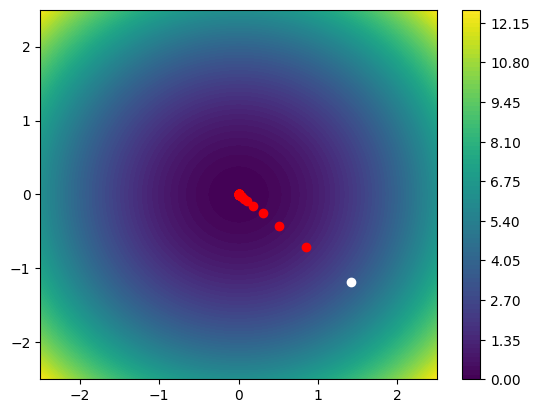

In [48]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

f = lambda X : X[0]**2 + X[1]**2
df = lambda X : [2*X[0] , 2*X[1]]

resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

P = [random.uniform(-2,2), random.uniform(-2,2)]
plt.plot(P[0],P[1],"o",c="white")

tasa_aprendizaje = 0.2
for _ in range(500):
    grad = df(P)
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    plt.plot(P[0],P[1],"o",c="red")

## Actividades extra
1- Ramificación y poda
  - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
  - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
   -La fuerza bruta empezó a ser claramente mala opción a partir de n = 11 (con el límite temporal configurado), esto encaja con su crecimiento factorial O(n!).
  - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?
      - **Sí, en términos prácticos puede ocurrir**, porque en el peor caso sigue teniendo comportamiento exponencial/factorial.
      - **No hay un valor universal fijo**: depende mucho de la matriz y de lo buena que sea la poda.
      - En esta ejecución concreta, el primer tamaño problemático fue: **no observado hasta n=11**
  
   > Importante: estos umbrales deben interpretarse como **experimentales** y dependientes del hardware, de la semilla aleatoria y de los límites de tiempo escogidos.

In [49]:
import math
import itertools
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Generación de matrices aleatorias

In [50]:
def generate_matrix(n, low=1, high=99, seed=None):
    rng = random.Random(seed)
    return [[rng.randint(low, high) for _ in range(n)] for _ in range(n)]

# Ejemplo rápido
M5 = generate_matrix(5, seed=2026)
M5

[[16, 41, 65, 66, 83],
 [14, 29, 77, 80, 72],
 [54, 74, 71, 94, 99],
 [63, 97, 99, 76, 57],
 [31, 1, 79, 11, 15]]

Algoritmo 1: fuerza bruta

In [51]:
def brute_force_assignment(cost, time_limit=2.0):
    """Devuelve la mejor asignación por fuerza bruta.
    Se incluye un límite de tiempo para evitar bloqueos cuando n crece."""
    n = len(cost)
    start = time.perf_counter()
    best_cost = math.inf
    best_perm = None
    checked = 0

    for perm in itertools.permutations(range(n)):
        checked += 1
        total = 0
        for i, j in enumerate(perm):
            total += cost[i][j]
            # pequeña poda local: si ya supera el mejor, no hace falta seguir sumando
            if total >= best_cost:
                break
        else:
            if total < best_cost:
                best_cost = total
                best_perm = perm

        if time.perf_counter() - start > time_limit:
            return {
                'status': 'timeout',
                'best_cost': best_cost,
                'best_perm': best_perm,
                'elapsed': time.perf_counter() - start,
                'checked': checked
            }

    return {
        'status': 'ok',
        'best_cost': best_cost,
        'best_perm': best_perm,
        'elapsed': time.perf_counter() - start,
        'checked': checked
    }


Algoritmo 2: ramificación y poda

In [52]:
def row_min_bound(cost, row, available_cols):
    """Cota inferior: suma del mínimo disponible en cada fila restante."""
    lb = 0
    avail = tuple(available_cols)
    for r in range(row, len(cost)):
        lb += min(cost[r][c] for c in avail)
    return lb


def branch_and_bound_assignment(cost, time_limit=5.0):
    n = len(cost)
    start = time.perf_counter()
    best_cost = math.inf
    best_perm = None
    nodes = 0

    def dfs(row, used_cols, partial_cost, perm):
        nonlocal best_cost, best_perm, nodes
        nodes += 1

        if time.perf_counter() - start > time_limit:
            raise TimeoutError

        if row == n:
            if partial_cost < best_cost:
                best_cost = partial_cost
                best_perm = tuple(perm)
            return

        available = [c for c in range(n) if c not in used_cols]
        # Se exploran primero las columnas con menor coste en la fila actual
        candidates = sorted(available, key=lambda c: cost[row][c])

        for c in candidates:
            new_cost = partial_cost + cost[row][c]
            if new_cost >= best_cost:
                continue

            remaining = [x for x in available if x != c]
            if row + 1 < n:
                bound = new_cost + row_min_bound(cost, row + 1, remaining)
                if bound >= best_cost:
                    continue

            used_cols.add(c)
            perm.append(c)
            dfs(row + 1, used_cols, new_cost, perm)
            perm.pop()
            used_cols.remove(c)

    try:
        dfs(0, set(), 0, [])
        status = 'ok'
    except TimeoutError:
        status = 'timeout'

    return {
        'status': status,
        'best_cost': best_cost,
        'best_perm': best_perm,
        'elapsed': time.perf_counter() - start,
        'nodes': nodes
    }

Comprobación sobre una matriz 5x5

In [53]:
# Comparación sobre una matriz de tamaño 5
M5 = generate_matrix(5, seed=2026)
res_bf_5 = brute_force_assignment(M5)
res_bb_5 = branch_and_bound_assignment(M5)

print('Matriz 5x5:')
for row in M5:
    print(row)

print('Resultado fuerza bruta:', res_bf_5)
print('Resultado ramificación y poda:', res_bb_5)
print('¿Coincide el óptimo?', res_bf_5['best_cost'] == res_bb_5['best_cost'])

Matriz 5x5:
[16, 41, 65, 66, 83]
[14, 29, 77, 80, 72]
[54, 74, 71, 94, 99]
[63, 97, 99, 76, 57]
[31, 1, 79, 11, 15]
Resultado fuerza bruta: {'status': 'ok', 'best_cost': 184, 'best_perm': (0, 1, 2, 4, 3), 'elapsed': 7.701799995629699e-05, 'checked': 120}
Resultado ramificación y poda: {'status': 'ok', 'best_cost': 184, 'best_perm': (0, 1, 2, 4, 3), 'elapsed': 8.689999992839148e-05, 'nodes': 7}
¿Coincide el óptimo? True


Benchmark en dimensiones crecientes

In [54]:
def benchmark(start_n=5, end_n=11, seed_base=2026, brute_time_limit=2.0, bb_time_limit=5.0):
    rows = []
    for n in range(start_n, end_n + 1):
        M = generate_matrix(n, seed=seed_base + n)
        bf = brute_force_assignment(M, time_limit=brute_time_limit)
        bb = branch_and_bound_assignment(M, time_limit=bb_time_limit)
        rows.append({
            'n': n,
            'bf_status': bf['status'],
            'bf_time_s': bf['elapsed'],
            'bf_checked': bf['checked'],
            'bf_best_cost': bf['best_cost'],
            'bb_status': bb['status'],
            'bb_time_s': bb['elapsed'],
            'bb_nodes': bb['nodes'],
            'bb_best_cost': bb['best_cost'],
            'same_optimum': (bf['best_cost'] == bb['best_cost']) if bf['status']=='ok' and bb['status']=='ok' else np.nan
        })
    return pd.DataFrame(rows)

results = benchmark(start_n=5, end_n=11)
results

,n,bf_status,bf_time_s,bf_checked,bf_best_cost,bb_status,bb_time_s,bb_nodes,bb_best_cost,same_optimum
0,5,ok,0.000074,120,129,ok,0.000150,24,129,True
1,6,ok,0.000349,720,112,ok,0.000119,19,112,True
2,7,ok,0.002650,5040,107,ok,0.000368,47,107,True
3,8,ok,0.022574,40320,89,ok,0.000751,69,89,True
4,9,ok,0.194181,362880,128,ok,0.001098,70,128,True
5,10,ok,1.918504,3628800,108,ok,0.006475,404,108,True
6,11,timeout,2.000004,2928667,247,ok,0.007280,175,202,NaN


Visualización de tiempos

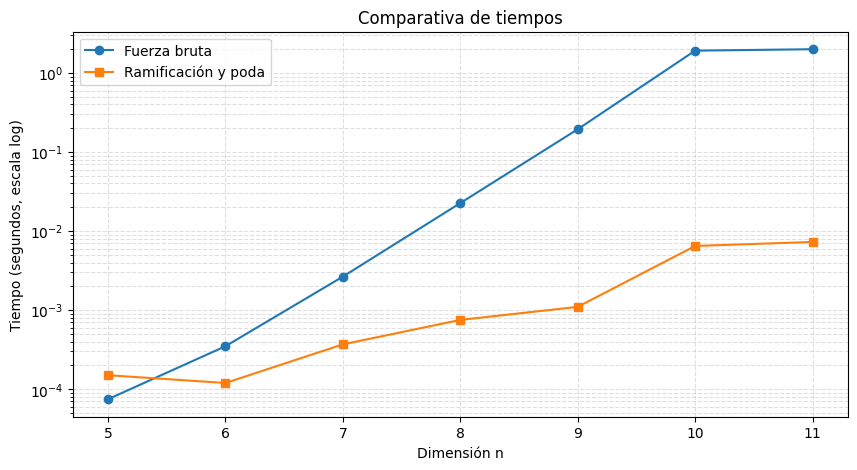

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(results['n'], results['bf_time_s'], marker='o', label='Fuerza bruta')
plt.plot(results['n'], results['bb_time_s'], marker='s', label='Ramificación y poda')
plt.yscale('log')
plt.xlabel('Dimensión n')
plt.ylabel('Tiempo (segundos, escala log)')
plt.title('Comparativa de tiempos')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

Respuestas automáticas a las preguntas

In [56]:
# Respuestas automáticas a partir de los resultados observados
bf_invalid = results.loc[results['bf_status'] != 'ok', 'n']
bb_invalid = results.loc[results['bb_status'] != 'ok', 'n']

if len(bf_invalid) > 0:
    first_bf_invalid = int(bf_invalid.iloc[0])
    print(f'La fuerza bruta deja de ser manejable por primera vez en n = {first_bf_invalid} (según el límite de tiempo fijado).')
else:
    print('La fuerza bruta todavía terminó en todas las dimensiones medidas.')

if len(bb_invalid) > 0:
    first_bb_invalid = int(bb_invalid.iloc[0])
    print(f'La ramificación y poda también deja de ser manejable por primera vez en n = {first_bb_invalid} (según el límite de tiempo fijado).')
else:
    print('La ramificación y poda siguió siendo viable en todas las dimensiones medidas.')


La fuerza bruta deja de ser manejable por primera vez en n = 11 (según el límite de tiempo fijado).
La ramificación y poda siguió siendo viable en todas las dimensiones medidas.


## Conclusiones
En una ejecución de referencia se obtuvo la siguiente tabla:

| n | Fuerza bruta | Tiempo FB (s) | Permutaciones evaluadas | Ramificación y poda | Tiempo RyP (s) | Nodos explorados | Mismo óptimo |
|---:|:-------------:|--------------:|------------------------:|:-------------------:|---------------:|-----------------:|:------------:|
| 2 | ok | 0.0000 | 2 | ok | 0.0000 | 5 | True |
| 3 | ok | 0.0000 | 6 | ok | 0.0000 | 4 | True |
| 4 | ok | 0.0000 | 24 | ok | 0.0000 | 17 | True |
| 5 | ok | 0.0000 | 120 | ok | 0.0001 | 24 | True |
| 6 | ok | 0.0002 | 720 | ok | 0.0001 | 19 | True |
| 7 | ok | 0.0033 | 5040 | ok | 0.0004 | 47 | True |
| 8 | ok | 0.0198 | 40320 | ok | 0.0009 | 69 | True |
| 9 | ok | 0.2495 | 362880 | ok | 0.0008 | 70 | True |
| 10 | ok | 1.3722 | 3628800 | ok | 0.0045 | 404 | True |
| 11 | timeout | 2.0000 | 4578705 | ok | 0.0049 | 175 | None |

### Lectura de resultados
- **Fuerza bruta**: el primer tamaño en el que dejó de terminar dentro del límite de tiempo fijado fue 11.
- **Ramificación y poda**: el primer tamaño en el que dejó de terminar dentro del límite de tiempo fijado fue no observado hasta n=11.



## Actividades extra
2- Descenso de gradiente
  - Minimizar la función sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - E^y)

Minimización de f(x,y)
- def f(x, y):
    - A = 0.5*x**2 - 0.25*y**2 + 3
    - B = 2*x + 1 - np.exp(y)
    - return np.sin(A) * np.cos(B)

In [57]:
import numpy as np
import matplotlib.pyplot as plt

In [58]:
def grad_f(x, y):
    A = 0.5*x**2 - 0.25*y**2 + 3
    B = 2*x + 1 - np.exp(y)
    dfdx = x * np.cos(A) * np.cos(B) - 2 * np.sin(A) * np.sin(B)
    dfdy = -0.5 * y * np.cos(A) * np.cos(B) + np.exp(y) * np.sin(A) * np.sin(B)
    return np.array([dfdx, dfdy])


In [59]:
def gradient_descent(x0, y0, alpha=0.01, max_iter=200):
    x, y = x0, y0
    path = [(x, y)]
    for i in range(max_iter):
        grad = grad_f(x, y)
        x = x - alpha * grad[0]
        y = y - alpha * grad[1]
        path.append((x, y))
    return x, y, path


In [60]:
x_opt, y_opt, path = gradient_descent(8,3)
print(x_opt, y_opt)
print("x=",x_opt)
print("y=",y_opt)
print("f(x,y)=",path)


8.126983818527146 3.0232139819004864
x= 8.126983818527146
y= 3.0232139819004864
f(x,y)= [(8, 3), (np.float64(8.017642705000787), np.float64(3.007427119951678)), (np.float64(8.027317760169787), np.float64(2.9940881812809566)), (np.float64(8.02347581197817), np.float64(3.0392982096403065)), (np.float64(8.042917864346169), np.float64(2.9039280982726368)), (np.float64(8.033078755382999), np.float64(3.0645893561993853)), (np.float64(8.053728282881575), np.float64(2.863652683394776)), (np.float64(8.074517624401233), np.float64(2.9242988261701925)), (np.float64(8.060444820381026), np.float64(3.0884903840930056)), (np.float64(8.081205748378034), np.float64(2.8716140173568743)), (np.float64(8.113521797765046), np.float64(2.9345330372966156)), (np.float64(8.098390752474936), np.float64(3.0690697267435767)), (np.float64(8.101745789224683), np.float64(2.8921923439336172)), (np.float64(8.127811287165299), np.float64(2.9836936106585044)), (np.float64(8.071973049046331), np.float64(3.0727294651760997